In [305]:
import numpy as np
import math
import pandas as pd
import cv2
import os
import re
import tqdm
from scipy.io import loadmat
from pdf2image import convert_from_path

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

from PIL import Image
import pytesseract

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import backend as K

#from utils import *

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from keras.callbacks import ModelCheckpoint
from keras.optimizers import Adam, SGD
from keras.layers import *

from keras.applications import MobileNetV2
from keras.applications import InceptionResNetV2

from keras.models import Model
from keras.models import model_from_json

from keras.models import load_model

import difflib # for fuzzy logic for closest match between strings


In [306]:
def all_boxes(pred_bom):
    
    boxes_list = []
    boxes_other_list = []
    #pred_bom = cv2.imread(pred_bom_id)
    pred_bom_gray = cv2.cvtColor(pred_bom, cv2.COLOR_BGR2GRAY)

    x_pil = Image.fromarray(pred_bom_gray)
    display(x_pil)

    ##thresholding the image to a binary image
    thresh,img_bin = cv2.threshold(pred_bom_gray,0,255,cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    #x_pil = Image.fromarray(img_bin)
    #display(x_pil)

    #inverting the image 
    img_bin_invert = 255-img_bin

    #img_pil = Image.fromarray(img_bin_invert)
    #display(img_pil) 

    #print(pred_bom_gray.shape[1], ',', img_bin.shape[1], ',', img_bin_invert.shape[1])
      
    # Length(width) of kernel as 100th of total width
    #kernel_len = pred_bom_gray.shape[1]//100

    # added on 19/3/2025
    kernel_len = 25

    ## Defining a vertical kernel to detect all vertical lines of image 
    ver_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, kernel_len))

    # Defining a horizontal kernel to detect all horizontal lines of image
    hor_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_len, 1))

    #Use vertical kernel to detect and save the vertical lines in a jpg
    image_1 = cv2.erode(img_bin_invert, ver_kernel, iterations=3)
    vertical_lines = cv2.dilate(image_1, ver_kernel, iterations=3)
    #x_pil = Image.fromarray(vertical_lines)
    #display(x_pil)

    #Use horizontal kernel to detect and save the horizontal lines in a jpg
    image_2 = cv2.erode(img_bin_invert, hor_kernel, iterations=3)
    horizontal_lines = cv2.dilate(image_2, hor_kernel, iterations=3)
    #x_pil = Image.fromarray(horizontal_lines)
    #display(x_pil)
    
    # Combine horizontal and vertical lines in a new third image, with both having same weight.
    img_vh = cv2.addWeighted(vertical_lines, 0.5, horizontal_lines, 0.5, 0.0)
    #x_pil = Image.fromarray(img_vh)
    #display(x_pil)

    # A kernel of 2x2
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    #print('Final kernel = ', kernel)

    img_vh_d = cv2.dilate(img_vh, kernel, iterations=2)

    #img_vh_d_pil = Image.fromarray(img_vh_d)
    #display(img_vh_d_pil)

    # Defining the cell boxes of img_vh

    contours_1, hierarchy = cv2.findContours(img_vh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    boxes_other = np.zeros((len(contours_1), 4))

    for i in range(len(contours_1)):
    
        cnt = contours_1[i]
        x, y, w, h = cv2.boundingRect(cnt)
        boxes_other[i, 0] = x
        boxes_other[i, 1] = y
        boxes_other[i, 2] = w
        boxes_other[i, 3] = h
    
    boxes_other_list.append(boxes_other)
    # Defining the cell boxes

    contours, hierarchy = cv2.findContours(img_vh_d, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    boxes = np.zeros((len(contours), 4))

    for i in range(len(contours)):
    
        cnt = contours[i]
        x, y, w, h = cv2.boundingRect(cnt)
        boxes[i, 0] = x
        boxes[i, 1] = y
        boxes[i, 2] = w
        boxes[i, 3] = h

    # print(len(boxes))
        
    boxes_list.append(boxes)
    
    return boxes_list, boxes_other_list, img_vh, img_vh_d   ## in format x, y, w, h. and boxes list is the list of horizontal lines in between 
                                            ## all vertical lines.


In [307]:
## For a valid box, same y value should appear at least 3 times for 'Sl.No.', 'Qty' and 'Description' columns.
## Also no y value of '0' is considered for valid boxes.

def filter_arrays(array_list):
    filtered_list = []  # List to store filtered arrays

    for arr in array_list:
        # Ensure the array is not empty
        if arr.size == 0:
            continue

        # Step 1: Identify y-values appearing at least 3 times
        y_values = arr[:, 1]
        unique_y, counts = np.unique(y_values, return_counts=True)

        # Keep only y-values appearing at least 3 times
        valid_y_values = {y for y, c in zip(unique_y, counts) if c >= 3}

        # Filter rows with these valid y-values
        filtered_arr = np.array([row for row in arr if row[1] in valid_y_values])

        # Step 2: Find the last occurrence of y = 0
        if filtered_arr.size > 0:
            last_zero_index = np.where(filtered_arr[:, 1] == 0)[0]
            if last_zero_index.size > 0:
                last_zero_index = last_zero_index[-1]  # Last occurrence index
                filtered_arr = filtered_arr[last_zero_index + 1:]  # Keep rows after

        # Add to the final list only if it's non-empty
        if filtered_arr.size > 0:
            filtered_list.append(filtered_arr)  # Corrected the append operation

    return filtered_list  # Return the list of filtered arrays


In [309]:
def find_bottom_left_one_rev(bom_boxes, pred_bom):
    """
    Find the bottom-most left-most box containing '1'
    """

    boxes_1 = filter_arrays(bom_boxes)
    boxes = sorted(boxes_1[0], key=lambda b: (b[1], b[0]))  # Sort by y (bottom-first), then x (left-first)
    #print('++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++')
    #print(boxes)
    # Convert list of arrays into a NumPy array
    boxes_np = np.array(boxes)

    # Step 1: Find the minimum x-value, excluding y=0
    #valid_boxes = boxes_np[boxes_np[:, 1] > 0]  # Keep only boxes with y > 0
    #min_x = np.min(valid_boxes[:, 0])  # Get minimum x
    min_x = np.min(boxes_np[:, 0])  # Get minimum x

    # Step 2: Get all boxes with this min_x value
    #filtered_boxes = valid_boxes[valid_boxes[:, 0] == min_x]
    filtered_boxes = boxes_np[boxes_np[:, 0] == min_x]
    
    for box in filtered_boxes:
        
        x, y, w, h = map(int, box)  # Convert to int
        
        x_c = x + 2
        y_c = y + 2
        w_c = w - 4
        h_c = h - 4
        pred_bom_gray = cv2.cvtColor(pred_bom, cv2.COLOR_BGR2GRAY)
        roi = pred_bom_gray[y_c:y_c+h_c, x_c:x_c+w_c]  # Crop the region - increase of x,y and reduction of w,h is very 
        #important for text accuracy
        sharp_kernel = np.array([[0, -1, 0], [-1, 5,-1], [0, -1, 0]])
        roi_sharp = cv2.filter2D(roi, -1, sharp_kernel)
        _, cell_bin = cv2.threshold(roi_sharp, 150, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
        #text = pytesseract.image_to_string(roi, config='--psm 6').strip()  # OCR
        text = pytesseract.image_to_string(cell_bin, config='--psm 6 --oem 3').strip()  # OCR
        #print('text =', text)
        if text == '1':
            return (x, y, w, h)  # Return coordinates of this box
    
    return None  # If not found

def draw_horizontal_line_if_needed(pred_bom, x, y, w, h):
    """
    Check if the longest horizontal line below the given box has another such line below it.
    If not, draw a new horizontal line at the bottom of the image.

    :param image_path: Path to the input image
    :param x, y, w, h: Coordinates of the bottom-most-left-most box containing "1"
    :return: Modified image
    """
    
    # Convert image to grayscale
    image = cv2.cvtColor(pred_bom, cv2.COLOR_BGR2GRAY)
    
    # Apply binary threshold
    _, img_bin = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    
    # Invert image (white background, black lines)
    img_bin_inv = 255 - img_bin
    
    # Define horizontal kernel
    kernel_len = image.shape[1] // 100
    hor_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_len, 1))

    # Extract horizontal lines
    hor_lines = cv2.erode(img_bin_inv, hor_kernel, iterations=3)
    hor_lines = cv2.dilate(hor_lines, hor_kernel, iterations=3)

    #img_pil = Image.fromarray(hor_lines)
    #display(img_pil)
    #print('=============================================================')
    # Find contours of horizontal lines
    contours, _ = cv2.findContours(hor_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Convert contours to (x, y, w, h) format
    hor_lines_list = [cv2.boundingRect(cnt) for cnt in contours]

    # Sort lines based on the y-coordinate (bottom-most first)
    hor_lines_list = sorted(hor_lines_list, key=lambda x: x[1], reverse=True)
    #print(hor_lines_list)
    #print('=============================================================')

    # Find the longest horizontal line immediately below this box
    # Find the smallest y-value that is greater than y
    filtered_values = [item for item in hor_lines_list if item[1] > y]

    # Get the entry with the minimum y-value
    if filtered_values:
        longest_line = min(filtered_values, key=lambda x: x[1]) 
    #print(longest_line)
    #print('=============================================================')
        
    if longest_line:
        x_longest, y_longest, w_longest, _ = longest_line

        # Check if another horizontal line exists below it with equal or greater width
        for x_line, y_line, w_line, h_line in hor_lines_list:
            if y_line > y_longest and w_line >= w_longest:
                print("A longer or equal horizontal line exists below. No need to draw a new line.")
                return pred_bom  # No need to draw a new line

        # If no such line exists, draw a new horizontal line
        #print("No longer horizontal line found. Drawing a new line at the bottom.")
        # img_color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        img_height, img_width = pred_bom.shape[:2]
        y_new_line = img_height - 2 # two pixel above the bottom edge
        cv2.line(pred_bom, (0, y_new_line), (img_width, y_new_line), (0, 0, 0), 2)
        
        return pred_bom

    else:
        # print("No horizontal line found below the given box.")
        return pred_bom  # No modifications needed


In [310]:
## Take out header boxes and all other box info for all items separately :

def header_and_item(pred_bom_corrected):
    
    bom_boxes_first,_,_,_ = all_boxes(pred_bom_corrected)
    bom_boxes = filter_arrays(bom_boxes_first)
    #print(bom_boxes)
    #print(type(bom_boxes))

    for i in range(len(bom_boxes)):   # for single bom drawings, len(bom_boxes) is always 1

        if i == 0:
            col_count_list = []
            header_boxes_list = []
            bom_boxes_list = []
            item_index_width_list = []

        #boxes_1 = bom_boxes[i][1:]   ## removing the line of full box i.e. removing 0th row
        #boxes_1_original = remove_before_last_zero(bom_boxes)
        #boxes_1 = boxes_1_original[0]
        boxes_1 = bom_boxes[0]
        
        ## Find number of columns i.e. max occurance of any y value :

        y_list = boxes_1[:, 1].tolist()   ## since boxes are in x,y,w,h format (output from cv2.boundingRect)

        col_count_array = np.bincount(y_list)  ## no. of occurances of each y-value
        col_count = col_count_array.max()  ## max. no. of occurances of any one y-value

        #print('No. of columns = ', col_count)
        

        # Now find the Header row :

        # In drawings, header row is always at the bottom.
        # Output of cv2.boundingRect always starts with the box of complete BOM
        # After this 1st row, the output starts with the bottom_most_right_most (in this order) box details.

        # So, y value of boxes[1] is the bottom_most-right_most (in this order) cell y value.

        y_bmrm_cell = boxes_1[0][1]  # y value of 1st bottom most cell

        # If occurances of this y value of 1st bottom most cell = number of columns, then this is the y value of Header Row

        num_col = y_list.count(y_bmrm_cell)   ## no. of occurances of y_bmrm_cell value 

        if num_col == col_count:
    
            y_header_row = y_bmrm_cell
            item_index_width = boxes_1[col_count-1, 2]  # This is the width of the 1st column i.e. 'Item No.' column
            bom_boxes_1 = boxes_1[1:]   ## remove 1st header row for bom consideration
    
        else:
        
            y_next_cell = boxes_1[1][1]

            num_col = y_list.count(y_next_cell)

            if num_col == col_count:
    
                y_header_row = y_next_cell
                item_index_width = boxes_1[col_count, 2]
                bom_boxes_1 = boxes_1[2:]    ## remove 1st 2 rows for bom consideration

        header_boxes = boxes_1[boxes_1[:, 1] == y_header_row] #######*************#########
    
        bom_boxes = bom_boxes_1[bom_boxes_1[:, 1] != y_header_row]
        
        col_count_list.append(col_count)
        item_index_width_list.append(item_index_width)
        header_boxes_list.append(header_boxes)
        bom_boxes_list.append(bom_boxes)
    
    return col_count_list, item_index_width_list, header_boxes_list, bom_boxes_list  ## all boxes in x, y, w, h format


In [311]:
# Function to standardize column names using difflib
def standardize_headers(df, reference_headers):
    standardized_cols = {
        col: difflib.get_close_matches(col, reference_headers, n=1, cutoff=0.6)[0] if difflib.get_close_matches(col, reference_headers, n=1, cutoff=0.6) else col
        for col in df.columns
    }
    return df.rename(columns=standardized_cols)


In [312]:
def bom_df_rev(pred_bom_id):

    pred_bom = cv2.imread(pred_bom_id)

    if pred_bom is None:
        print("Error: Image not found or could not be loaded.")
        return None, None, None

    boxes_list, _, _, _ = all_boxes(pred_bom)
    #print(boxes_list)
    #print('======================================================================')
    #x, y, w, h = find_bottom_left_one_rev(boxes_list, pred_bom)
    #print(x, y, w, h)

    result = find_bottom_left_one_rev(boxes_list, pred_bom)
    if result:  # Check if function returned a valid box
        x, y, w, h = result
        #print(x, ',', y, ',', w, ',', h)
    else:
        print("No suitable box found")

    # Run function and get modified image
    pred_bom_corrected = draw_horizontal_line_if_needed(pred_bom, x, y, w, h)
    
    print('=========================== ALL OK ABOVE THIS ============================')
    # Extract header and item details
    col_count_list, item_index_width_list, header_boxes_list, bom_boxes_list = header_and_item(pred_bom_corrected)
    #gridless_bom_image, left_margin = remove_grid_lines(pred_bom_id)
    print(bom_boxes_list)
    # Ensure we have header boxes
    if not header_boxes_list or len(header_boxes_list) == 0:
        #print("Error: No header boxes found!")
        return None, None, None

    # Extract header column widths
    width_list = header_boxes_list[0][:, 2]  
    x_list = header_boxes_list[0][:, 0]
    #print('width list = ', width_list)
    # Find the frequency of column widths
    width_frequency = np.unique(width_list, return_counts=True)[1]  
    #print('Width Frequency:', width_frequency)

    # Get all column widths from BOM items
    all_width_list = bom_boxes_list[0][:, 2].tolist()
    row_count_array = np.bincount(all_width_list)  
    row_count_apparent = row_count_array.max()
    
    # Estimate row count
    row_count = row_count_apparent // np.max(width_frequency) if np.max(width_frequency) != 0 else 0
    #print('Estimated Row Count:', row_count)

    sharp_kernel = np.array([[0, -1, 0], [-1, 5,-1], [0, -1, 0]])
    # Extract header text
    header_text = []
    for box in header_boxes_list[0]:  
        x, y, w, h = map(int, box)  # Convert to integers
        #header_crop = pred_bom[y:y+h, x:x+w]

        x_c = x + 2
        y_c = y + 2
        w_c = w - 4
        h_c = h - 4
        pred_bom_gray = cv2.cvtColor(pred_bom_corrected, cv2.COLOR_BGR2GRAY)
        roi = pred_bom_gray[y_c:y_c+h_c, x_c:x_c+w_c]  # Crop the region - increase of x,y and reduction of w,h is very 
        #important for text accuracy
        roi_sharp = cv2.filter2D(roi, -1, sharp_kernel)
        
        #text = pytesseract.image_to_string(roi, config='--psm 6').strip()  # OCR
        text = pytesseract.image_to_string(roi_sharp, config='--psm 6 --oem 3').strip()  # OCR
        text = text.replace("\n", " ")  # Remove newlines ***** added on 20/3/2025
        header_text.append(text)

    header_text.append('drg_id')
    #header_text = [text.replace("\n", " ").strip() for text in header_text]  # Remove newlines ***** added on 20/3/2025 
    serialised_header_text = header_text[::-1]  # Reverse order
    print('****** UPTO Header Text ALL OK *******')
    # Extract BOM items
    bom_text = []
    for i, bom_boxes in enumerate(bom_boxes_list):
        y_unique = np.unique(bom_boxes[:, 1])[::-1]  # Reverse order
        #print('===================================================================')
        #print(y_unique)
        #print(col_count_list, '++', col_count_list[0])
        #print('===================================================================')
        for j in y_unique:
            bom_sub_text = []
            aa = np.ones((col_count_list[0], 4))  
            bb = bom_boxes[bom_boxes[:, 1] == j]  # Select only rows with matching Y
            
            #print('=== j ==', j)
            #print('length aa =', len(aa), 'aa shape = ', aa.shape, 'length bb =', len(bb), 'bb shape = ', bb.shape)
            #print('+++++++++++++++++++++++++++++++++++++++++++++++++++++')
            #print(bb)
            #print('+++++++++++++++++++++++++++++++++++++++++++++++++++++')
            #print("width_list = ", width_list)
            #print("x_list = ", x_list)
            for k in range(len(aa)):
                for l in range(len(bb)):
                    #print('value of k = ', k, 'x_list[k] = ', x_list[k])
                    #print('value of l = ', l, 'bb[l] = ', bb[l])
                    
                    if abs((bb[l][2] + bb[l][0]) - (width_list[k] + x_list[k])) <= 2:
                        aa[k, :] = bb[l, :]
                #print('========================== CHANGE OG K =============================')
            #print(aa)
            #print('CHECH-1-+++++++++++++++++++++++++++++++++++++++++++++++++++++')
            for k in range(len(aa)):
                x, y, w, h = map(int, aa[k])
                #print(x, ',', y, ',', w, ',', h)
                #print('CHECK-2-++++++++++++++++++++++++++++++++++++++++++++++++++++')

                if x == 1 and y == 1 and w == 1 and h == 1:
                   text = ' '  
                else:
                    x_c = x + 2
                    y_c = y + 2
                    w_c = w - 4
                    h_c = h - 4

                    cell_crop_image = pred_bom_gray[y_c:y_c+h_c, x_c:x_c+w_c]

                    if cell_crop_image is None or cell_crop_image.size == 0:
                        print("Error: cell_crop_image is empty or not loaded correctly.")

                    # Find the first column where any value < 10
                    col_indices = np.where(np.any(cell_crop_image < 10, axis=0))[0]  # Get all matching column indices

                    if col_indices.size > 0:  # Check if any column meets the condition
                        col_index = col_indices[0]  # First column where condition is met
                        start_col = max(0, col_index - 3)  # Keep 3 columns before
                        modified_arr = cell_crop_image[:, start_col:]
                        #print(f"Original Shape: {cell_crop_image.shape}")
                        #print(f"New Shape: {modified_arr.shape}")
                    else:
                        modified_arr = cell_crop_image  # Keep the original array unchanged

                    # OCR text extraction
                    cell_crop_sharp = cv2.filter2D(modified_arr, -1, sharp_kernel)
                    _, cell_bin = cv2.threshold(cell_crop_sharp, 150, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
        
                    #text = pytesseract.image_to_string(roi, config='--psm 6').strip()  # OCR
                    text = pytesseract.image_to_string(cell_bin, config='--psm 6 --oem 3').strip()  # OCR
                    #print("=================================================================================================")
            
                    text = text.replace("\n", " ")  # Remove newlines within extracted text
                    #if x == 248 and y == 409 and w ==  694 and h == 59:
                    
                # OCR text extraction
                #text = pytesseract.image_to_string(cell_bin, config='--psm 6 --oem 3').strip()
                #text = pytesseract.image_to_string(cell_bin, config='--psm 6 --oem 1 -c tessedit_char_whitelist=0123456789').strip()
                bom_sub_text.append(text)

            bom_id = ((pred_bom_id.split('/'))[-1].split('.'))[0] # making bom df with only drg no. and not with drg. path
            bom_sub_text.append(bom_id)  # Append image ID
            bom_text.append(bom_sub_text[::-1])  # Reverse order

    # Convert to DataFrame
    expected_cols = len(header_text)  # Expected column count
    filtered_bom_text = [row for row in bom_text if len(row) == expected_cols]

    # Convert to DataFrame
    df = pd.DataFrame(filtered_bom_text, columns=serialised_header_text)

    #df = pd.DataFrame(bom_text, columns=serialised_header_text)
    return df, bom_text, bom_sub_text


In [304]:
pred_bom_id = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/1039.jpg"
df, _, _ = bom_df_rev(pred_bom_id)

bom boxes are =  [array([[  40.,   17., 1312.,  133.],
       [1104.,  115.,  244.,   31.],
       [1212.,   79.,  136.,   33.],
       [1104.,   79.,  105.,   33.],
       [ 816.,   79.,  285.,   67.],
       [ 202.,   79.,  611.,   67.],
       [ 117.,   79.,   82.,   67.],
       [  44.,   79.,   70.,   67.],
       [1212.,   21.,  136.,   55.],
       [1104.,   21.,  105.,   55.],
       [ 816.,   21.,  285.,   55.],
       [ 202.,   21.,  611.,   55.],
       [ 117.,   21.,   82.,   55.],
       [  44.,   21.,   70.,   55.]])]


In [302]:
df.head()

,drg_id,TEM No,No OFF,DESCRIPTION,MATERIAL,UNIT,TOTAL
0,1039,1,1,PL 8 THK x 198 x 998 LG.,IS:2062 GR-B,,12.4


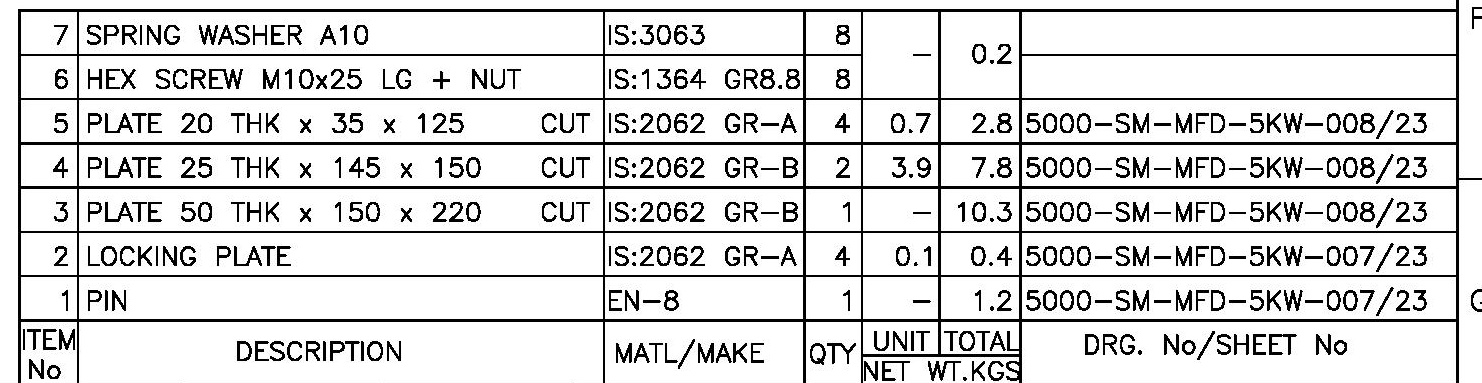

=========================== ALL OK ABOVE THIS ============================


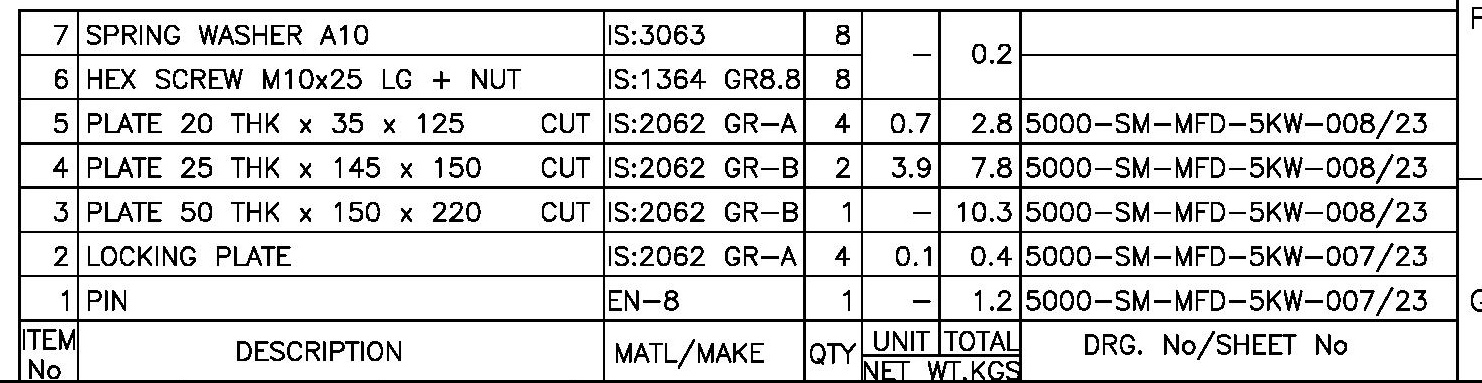

[array([[1023.,  278.,  434.,   42.],
       [ 942.,  278.,   78.,   42.],
       [ 864.,  278.,   75.,   42.],
       [ 807.,  278.,   55.,   42.],
       [ 606.,  278.,  198.,   42.],
       [  80.,  278.,  524.,   42.],
       [  22.,  278.,   56.,   42.],
       [1023.,  234.,  434.,   42.],
       [ 942.,  234.,   78.,   42.],
       [ 864.,  234.,   75.,   42.],
       [ 807.,  234.,   55.,   42.],
       [ 606.,  234.,  198.,   42.],
       [  80.,  234.,  524.,   42.],
       [  22.,  234.,   56.,   42.],
       [1023.,  190.,  434.,   42.],
       [ 942.,  190.,   78.,   42.],
       [ 864.,  190.,   75.,   42.],
       [ 807.,  190.,   55.,   42.],
       [ 606.,  190.,  198.,   42.],
       [  80.,  190.,  524.,   42.],
       [  22.,  190.,   56.,   42.],
       [1023.,  146.,  434.,   41.],
       [ 942.,  146.,   78.,   41.],
       [ 864.,  146.,   75.,   41.],
       [ 807.,  146.,   55.,   41.],
       [ 606.,  146.,  198.,   41.],
       [  80.,  146.,  524.,   41.],


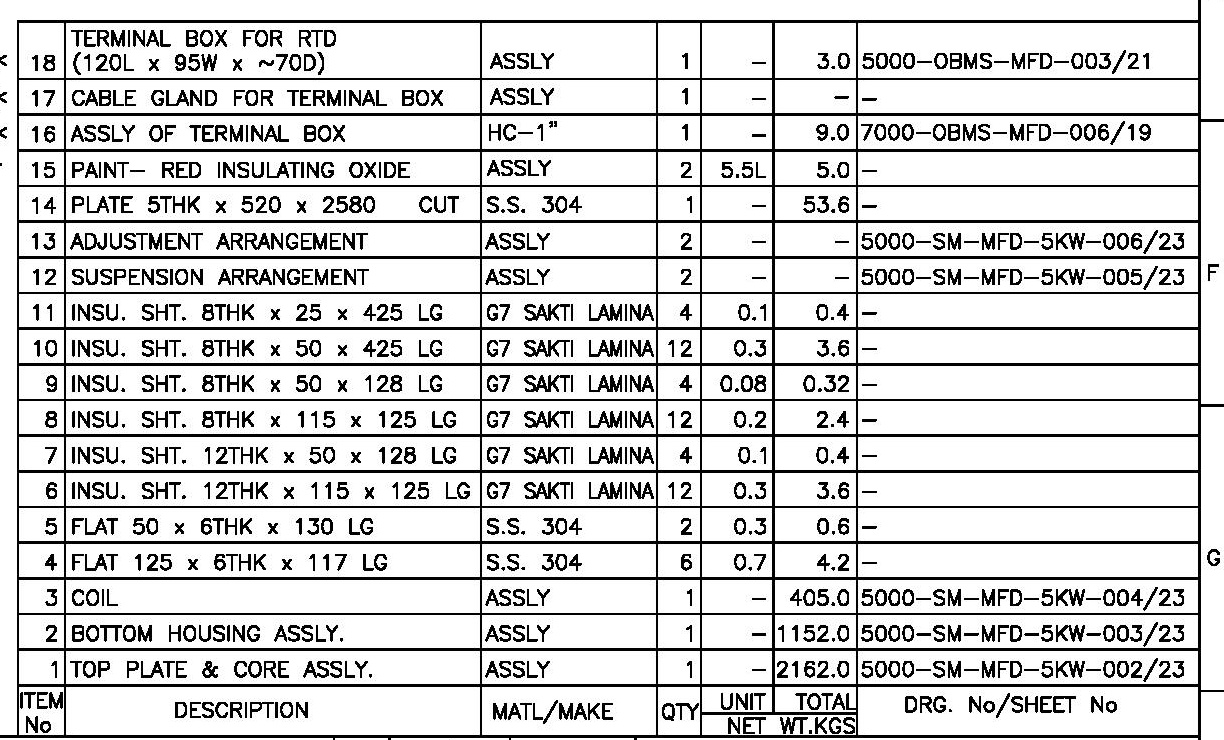

A longer or equal horizontal line exists below. No need to draw a new line.
=========================== ALL OK ABOVE THIS ============================


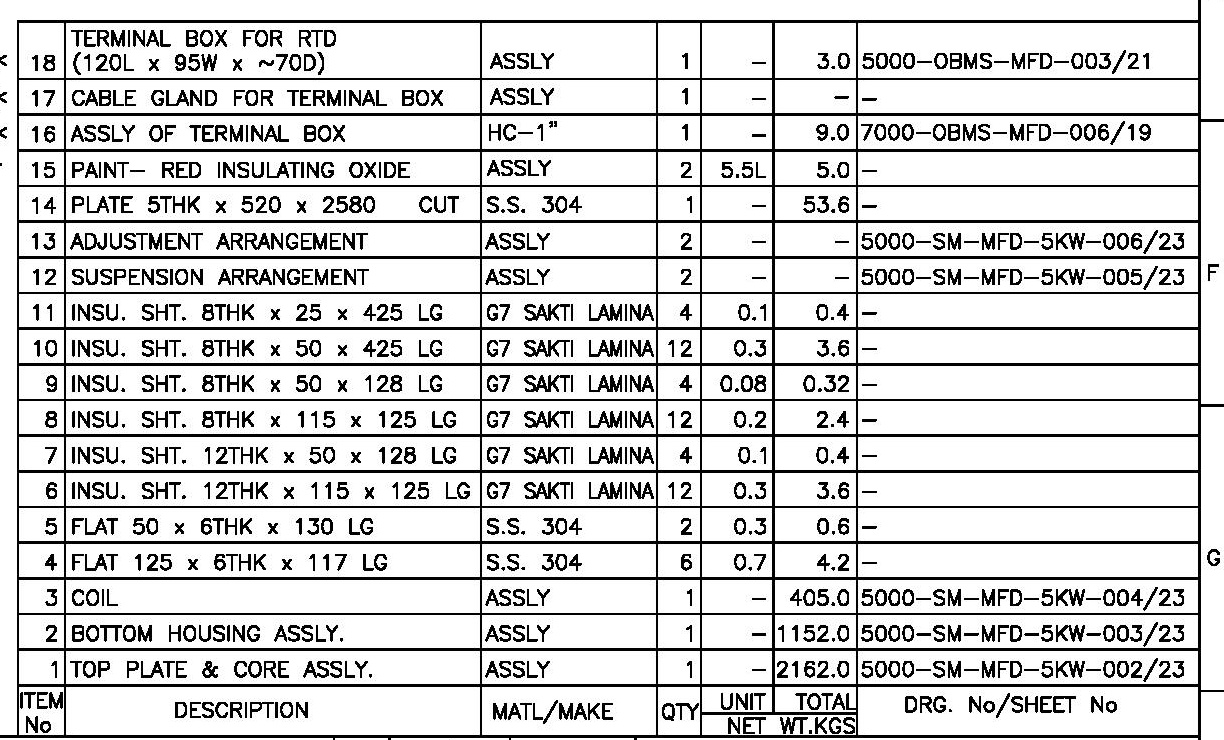

[array([[859., 652., 340.,  33.],
       [776., 652.,  81.,  33.],
       [703., 652.,  70.,  33.],
       [659., 652.,  42.,  33.],
       [483., 652., 174.,  33.],
       [ 67., 652., 414.,  33.],
       [ 20., 652.,  45.,  33.],
       [859., 616., 340.,  33.],
       [776., 616.,  81.,  33.],
       [703., 616.,  70.,  33.],
       [659., 616.,  42.,  33.],
       [483., 616., 174.,  33.],
       [ 67., 616., 414.,  33.],
       [ 20., 616.,  45.,  33.],
       [859., 581., 340.,  33.],
       [776., 581.,  81.,  33.],
       [703., 581.,  70.,  33.],
       [659., 581.,  42.,  33.],
       [483., 581., 174.,  33.],
       [ 67., 581., 414.,  33.],
       [ 20., 581.,  45.,  33.],
       [859., 545., 340.,  33.],
       [776., 545.,  81.,  33.],
       [703., 545.,  70.,  33.],
       [659., 545.,  42.,  33.],
       [483., 545., 174.,  33.],
       [ 67., 545., 414.,  33.],
       [ 20., 545.,  45.,  33.],
       [859., 509., 340.,  33.],
       [776., 509.,  81.,  33.],
       [7

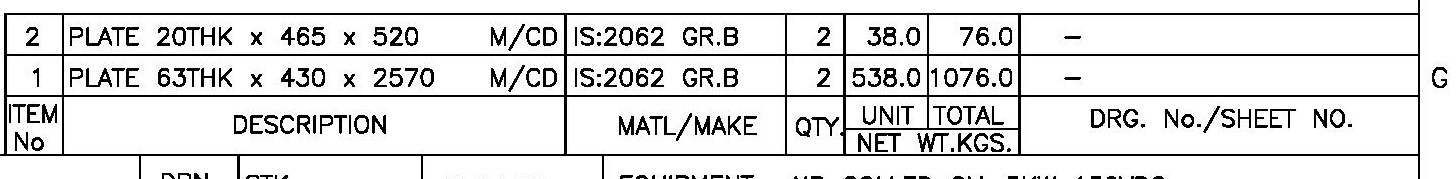

A longer or equal horizontal line exists below. No need to draw a new line.
=========================== ALL OK ABOVE THIS ============================


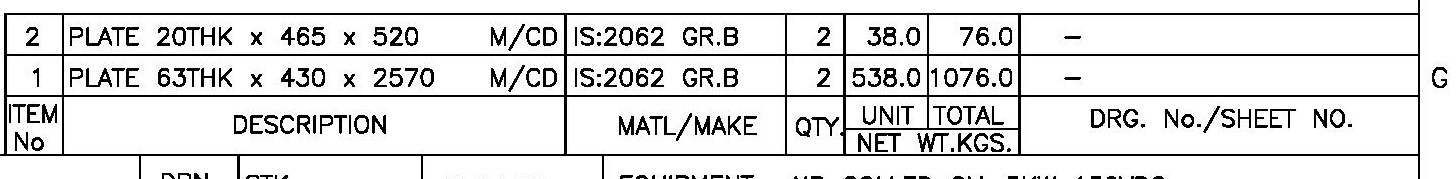

[array([[1022.,   57.,  397.,   39.],
       [ 930.,   57.,   89.,   39.],
       [ 847.,   57.,   81.,   39.],
       [ 788.,   57.,   56.,   39.],
       [ 568.,   57.,  218.,   39.],
       [  65.,   57.,  500.,   39.],
       [   8.,   57.,   55.,   39.],
       [1022.,   16.,  397.,   39.],
       [ 930.,   16.,   89.,   39.],
       [ 847.,   16.,   81.,   39.],
       [ 788.,   16.,   56.,   39.],
       [ 568.,   16.,  218.,   39.],
       [  65.,   16.,  500.,   39.],
       [   8.,   16.,   55.,   39.]])]
****** UPTO Header Text ALL OK *******
BOM Created for =  SM-MFD-5KW-003-23


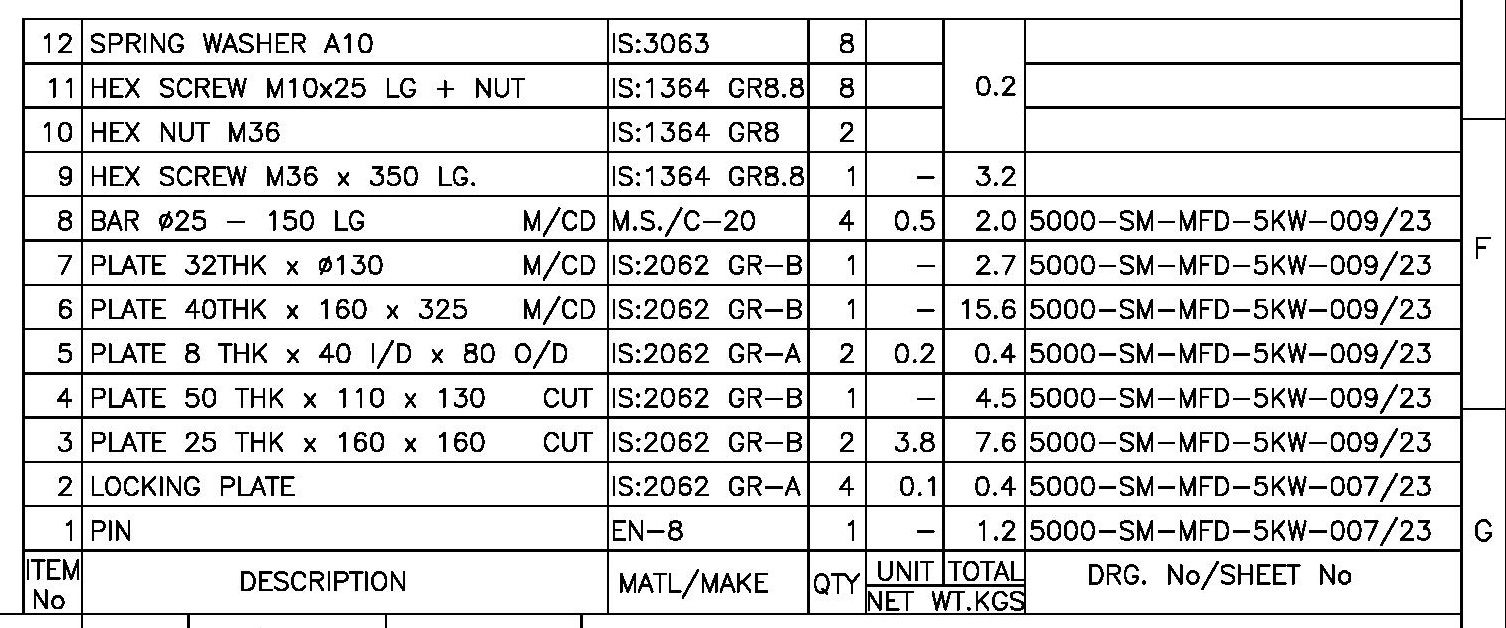

A longer or equal horizontal line exists below. No need to draw a new line.
=========================== ALL OK ABOVE THIS ============================


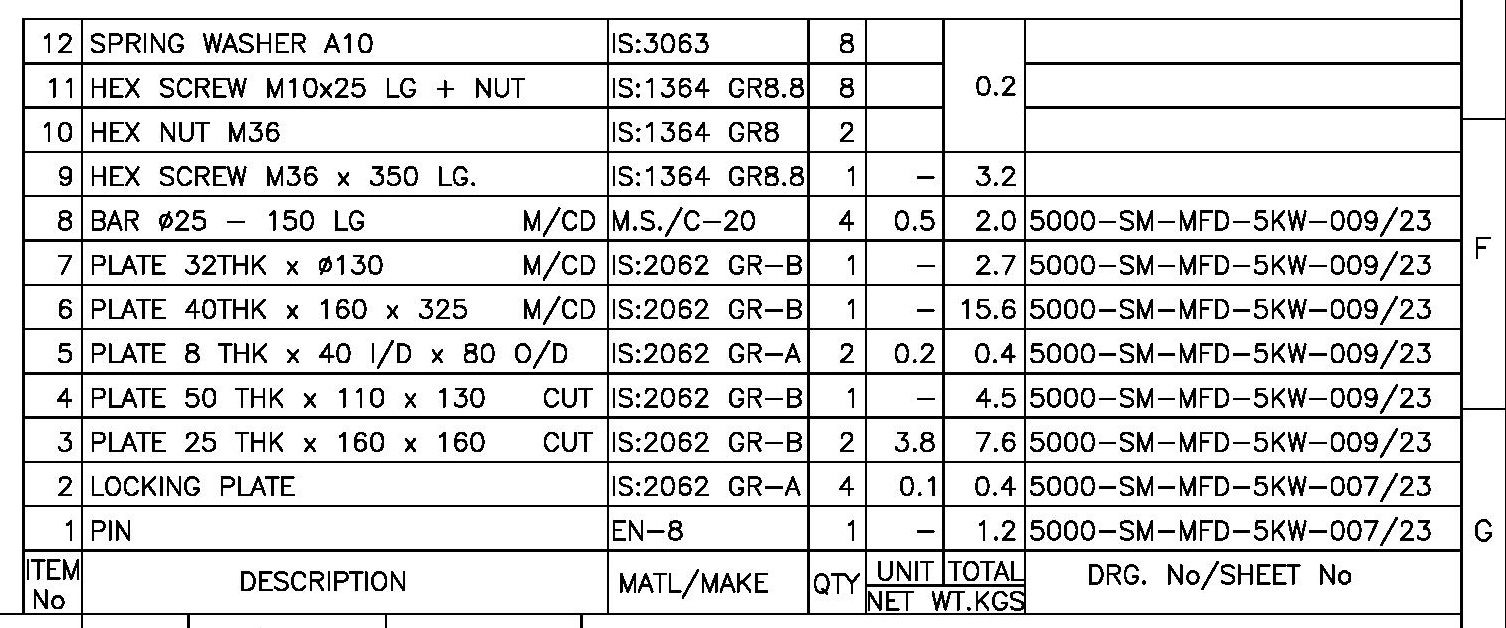

[array([[1027.,  508.,  434.,   42.],
       [ 946.,  508.,   79.,   42.],
       [ 868.,  508.,   75.,   42.],
       [ 811.,  508.,   55.,   42.],
       [ 610.,  508.,  198.,   42.],
       [  84.,  508.,  524.,   42.],
       [  26.,  508.,   56.,   42.],
       [1027.,  464.,  434.,   42.],
       [ 946.,  464.,   79.,   42.],
       [ 868.,  464.,   75.,   42.],
       [ 811.,  464.,   55.,   42.],
       [ 610.,  464.,  198.,   42.],
       [  84.,  464.,  524.,   42.],
       [  26.,  464.,   56.,   42.],
       [1027.,  420.,  434.,   42.],
       [ 946.,  420.,   79.,   42.],
       [ 868.,  420.,   75.,   42.],
       [ 811.,  420.,   55.,   42.],
       [ 610.,  420.,  198.,   42.],
       [  84.,  420.,  524.,   42.],
       [  26.,  420.,   56.,   42.],
       [1027.,  376.,  434.,   41.],
       [ 946.,  376.,   79.,   41.],
       [ 868.,  376.,   75.,   41.],
       [ 811.,  376.,   55.,   41.],
       [ 610.,  376.,  198.,   41.],
       [  84.,  376.,  524.,   41.],


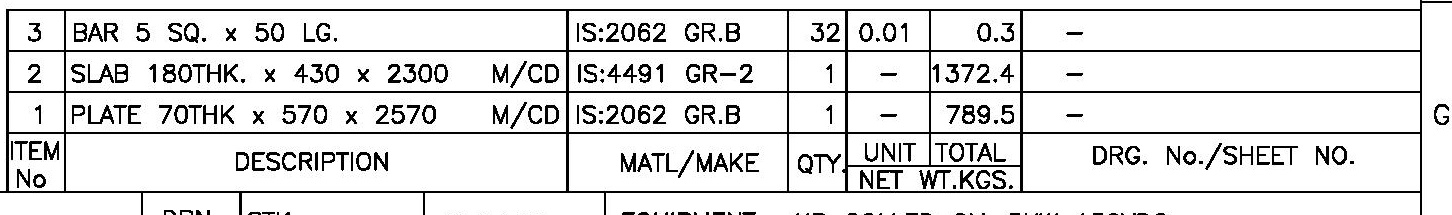

A longer or equal horizontal line exists below. No need to draw a new line.
=========================== ALL OK ABOVE THIS ============================


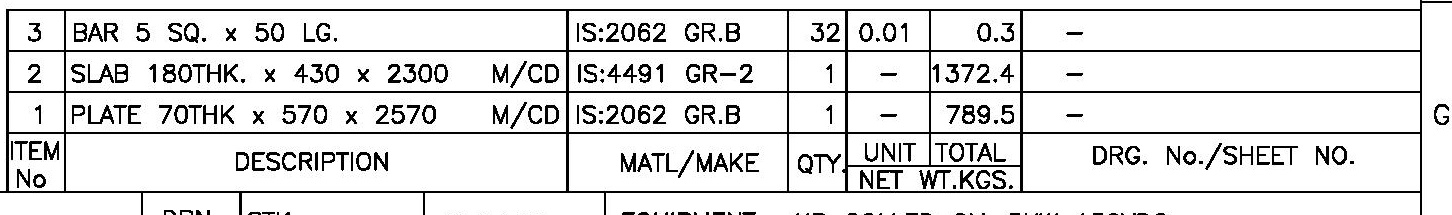

[array([[1024.,   94.,  397.,   39.],
       [ 932.,   94.,   89.,   39.],
       [ 849.,   94.,   81.,   39.],
       [ 790.,   94.,   56.,   39.],
       [ 570.,   94.,  218.,   39.],
       [  67.,   94.,  500.,   39.],
       [  10.,   94.,   55.,   39.],
       [1024.,   53.,  397.,   39.],
       [ 932.,   53.,   89.,   39.],
       [ 849.,   53.,   81.,   39.],
       [ 790.,   53.,   56.,   39.],
       [ 570.,   53.,  218.,   39.],
       [  67.,   53.,  500.,   39.],
       [  10.,   53.,   55.,   39.],
       [1024.,   12.,  397.,   39.],
       [ 932.,   12.,   89.,   39.],
       [ 849.,   12.,   81.,   39.],
       [ 790.,   12.,   56.,   39.],
       [ 570.,   12.,  218.,   39.],
       [  67.,   12.,  500.,   39.],
       [  10.,   12.,   55.,   39.]])]
****** UPTO Header Text ALL OK *******
BOM Created for =  SM-MFD-5KW-002-23
ALL BOM CREATED SUCCESSFULLY
Excel file saved successfully with two sheets!


In [313]:
# Path to the folder containing images
folder_path = "/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/project_1/" # Change this to your folder path

# List to store DataFrames
df_list = []

# Loop through all images in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith((".jpg", ".png", ".jpeg")):  # Add other image formats if needed
        image_path = os.path.join(folder_path, file_name)

        df, _, _ = bom_df_rev(image_path)  # Call your function

        if df is not None:  # Ensure df is valid
            bom_id = ((image_path.split('/'))[-1].split('.'))[0] # making bom df with only drg no. and not with drg. path
            print('BOM Created for = ', bom_id)

            df_list.append(df)

if df_list:

    # Take the header of the first DataFrame as the reference
    reference_headers = df_list[0].columns.tolist()

    # Apply standardization to all DataFrames (excluding the first, as it's already correct)
    df_list = [df_list[0]] + [standardize_headers(df, reference_headers) for df in df_list[1:]]

    # Concatenate all DataFrames
    final_df = pd.concat(df_list, ignore_index=True)
    final_df = final_df.dropna(axis=1, how="all")  # Drop completely empty columns
    print('ALL BOM CREATED SUCCESSFULLY')

else:
    print("No valid DataFrames generated.")

#final_df.to_excel("/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/project_1.xlsx", index=False)  # Saves without the index column

# Define column indexes to sort by (e.g., 1st and 3rd columns)
sort_columns_1 = [final_df.columns[0]]  # Sort by 0th column
sort_columns_2 = [final_df.columns[3], final_df.columns[2]]  # Sort by 3rd and 2nd column

# Sort DataFrame
final_df_sorted_1 = final_df.sort_values(by=sort_columns_1, ascending=True)
final_df_sorted_2 = final_df.sort_values(by=sort_columns_2, ascending=True)

# Save both original and sorted DataFrame in the same Excel file
with pd.ExcelWriter("/Users/subrata/workstation/jupyterFiles/yolo_data_file/pred_cropped_bom_jpg/project_1.xlsx") as writer:
    final_df_sorted_1.to_excel(writer, sheet_name="Original Data", index=False)
    final_df_sorted_2.to_excel(writer, sheet_name="Sorted Data", index=False)

print("Excel file saved successfully with two sheets!")


In [300]:
final_df_sorted_1.head(25)

,drg_id,TEM No,DESCRIPTION,MATL/MAKE,QTY,UNIT,TOTAL,DRG. No/SHEET No
21,SM-MFD-5KW-001-23,15,PAINT— RED INSULATING OXIDE,ASSLY,2,5.5L,5.0,
17,SM-MFD-5KW-001-23,11,"INSU, SHT. 8THK x 25 x 425 LG",G7 SAKTI LAMINA,4,0.1,0.4,
16,SM-MFD-5KW-001-23,10,INSU. SHT. 8THK x 50 x 425 LG,G7 SAKTI LAMINA,12,0.3,3.6,
15,SM-MFD-5KW-001-23,9,INSU. SHT. 8THK x 50 x 128 LG,G7 SAKTI LAMINA,4,0.08,0.32,
14,SM-MFD-5KW-001-23,8,INSU. SHT. 8THK x 115 x 125 LG,G7 SAKTI LAMINA,12,0.2,2.4,
13,SM-MFD-5KW-001-23,7,INSU. SHT. 12THK x 50 x 128 LG,G7 SAKTI LAMINA,4,0.1,0.4,
12,SM-MFD-5KW-001-23,6,INSU. SHT. 12THK x 115 x 125 LG,G7 SAKTI LAMINA,12,0.3,3.6,
11,SM-MFD-5KW-001-23,5,FLAT 50 x 6THK x 130 LG,S.S. 304,2,03,0.6,
10,SM-MFD-5KW-001-23,4,FLAT 125 x 6THK x 117 LG,5.8. 304,6,07,4.2,
9,SM-MFD-5KW-001-23,3,COIL,ASSLY,1,,405.0,"5000—SM—MFD—5KW—004,/23"
